# 02 Custom Mixture Development

Aim of this notebook: document the fitting-set development of the custom probabilistic mixture used as one of the five static NHS scorers.

It selects \(K\), fits the final six-component model on fitting accounts, interprets the fitted component profiles, and freezes the automation-oriented component set for downstream scoring.


## 0. Configuration


In [1]:
from pathlib import Path
import hashlib
import importlib
import json

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nhs_split_eval as se


FEATURE_PATH = Path("static_features_v2/feat_final.parquet")
FEATURE_META_PATH = Path("static_features_v2/feature_build_meta.json")
ACCOUNT_SPLIT_PATH = Path("account_split_static.json")

# Reuse previously generated mixture-fit results when available;
# missing results are regenerated automatically.
OUT = Path("custom_mixture_development")
OUT.mkdir(exist_ok=True)

# All cached and generated results from notebook 02a live in one folder.
BIC_TABLE_PATH = OUT / "custom_mixture_bic_scan.csv"
MIXTURE_STATE_PATH = OUT / "custom_mixture_K6_state.json"
PROFILE_TABLE_PATH = OUT / "Table_09_custom_mixture_component_profiles.csv"
MIXTURE_META_PATH = OUT / "mixture_development_meta.json"
FIGURE9_PATH = OUT / "Figure_09_mixture_bic_selection.png"

SEED = 42
K_RANGE = range(2, 11)
EXPECTED_SELECTED_K = 6
MACHINE_COMPONENTS = [0, 1, 2, 4]

# Expensive refits are opt-in.
RECOMPUTE_BIC_SCAN = False
REFIT_FINAL_MIXTURE = False

print("Configuration ready.")


Configuration ready.


## 1. Load fitting data

The custom mixture uses the five CORE5 behavioural dimensions, with event volume and destination fanout on their original count scales because they are modelled with count distributions.


In [2]:
def file_sha256(path):
    path = Path(path)
    h = hashlib.sha256()
    with path.open("rb") as f:
        for block in iter(lambda: f.read(1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


for required in [FEATURE_PATH, FEATURE_META_PATH, ACCOUNT_SPLIT_PATH]:
    if not required.exists():
        raise FileNotFoundError(f"Missing required input: {required}")

feature_meta = json.loads(FEATURE_META_PATH.read_text())
split_obj = json.loads(ACCOUNT_SPLIT_PATH.read_text())

expected_hash = feature_meta["output_hashes"]["feat_final"]
actual_hash = file_sha256(FEATURE_PATH)

if actual_hash != expected_hash:
    raise RuntimeError("Canonical feature table does not match notebook-01 provenance.")

fit_a = set(map(str, split_obj["fit"]))

con = duckdb.connect()
feat = con.execute(
    f"SELECT * FROM '{FEATURE_PATH.as_posix()}'"
).df()
con.close()

feat["u"] = feat["u"].astype(str)
fit_df = feat.loc[feat["u"].isin(fit_a)].reset_index(drop=True)

MIXTURE_FEATURES = [
    "period_strength",
    "iat_cv",
    "volume",
    "fanout",
    "quiet_frac",
]

missing = [c for c in MIXTURE_FEATURES if c not in fit_df.columns]
if missing:
    raise RuntimeError(f"Missing mixture features: {missing}")

mix = importlib.import_module("nhs_mixture")
fit_mixture_k = mix.fit_mixture_k
score_mixture_k = mix.score_mixture_k

print(f"Fit rows / accounts: {len(fit_df):,} / {fit_df['u'].nunique():,}")
print("Mixture features:", MIXTURE_FEATURES)


Fit rows / accounts: 62,310 / 17,734
Mixture features: ['period_strength', 'iat_cv', 'volume', 'fanout', 'quiet_frac']


## 2. Custom mixture specification

Within each component, event volume follows a Negative Binomial distribution truncated below 20, destination fanout a zero-truncated Negative Binomial, IAT-CV a Gamma distribution, periodicity a censored Gamma distribution, and the quiet-event count a Beta-Binomial distribution.

The five contributions are conditionally independent given the latent component. Periodicity is left-censored below 0.05 and right-censored at 300; missing IAT-CV or periodicity terms are omitted from the likelihood.


## 3. Fit candidate values of \(K\) and select the component count

The development procedure fits custom mixture models with \(K=2,\ldots,10\) on the fitting partition and records the BIC for each model. A saved scan in `custom_mixture_development/` is reused when available; otherwise the candidate models are fitted and the scan is generated automatically.

Set `RECOMPUTE_BIC_SCAN=True` only to force a fresh scan when a cache already exists.


BIC source: loaded from custom_mixture_development/custom_mixture_bic_scan.csv

=== Fitting-set BIC scan ===
 K       BIC  dBIC_to_next
 2 3138635.0       72340.0
 3 3066295.0       56457.0
 4 3009838.0       93181.0
 5 2916657.0       24855.0
 6 2891802.0       23763.0
 7 2868040.0       13721.0
 8 2854319.0        9384.0
 9 2844935.0       10772.0
10 2834163.0           NaN

Largest previous improvement at stopping step : 93,181
One-third stopping threshold                  : 31,060
Improvement into K=6                    : 24,855
Selected K                                    : 6


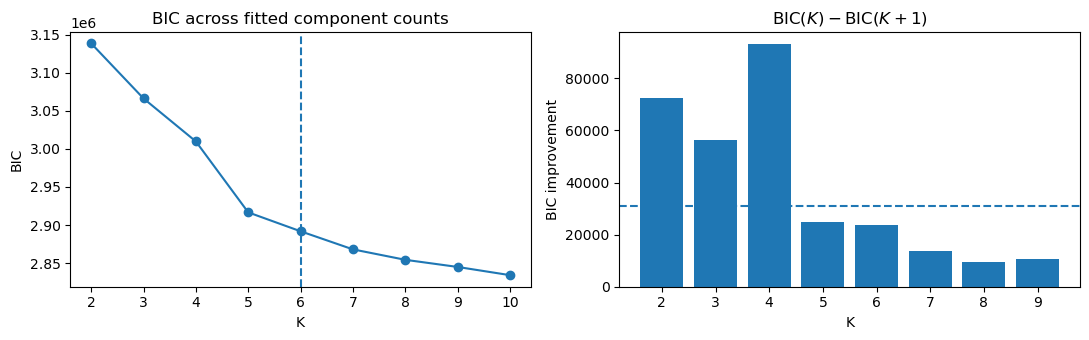

In [3]:
def fit_candidate_mixture(df, K, verbose=False):
    """Use the project seed explicitly for every candidate-K fit."""
    return fit_mixture_k(
        df,
        K=K,
        seed=SEED,
        verbose=verbose,
    )


if RECOMPUTE_BIC_SCAN or not BIC_TABLE_PATH.exists():
    reason = (
        "forced recomputation"
        if RECOMPUTE_BIC_SCAN
        else "no saved BIC scan found"
    )
    print(f"Recomputing K=2,...,10 ({reason})...")

    _, bic_table = se.choose_k(
        fit_df,
        fit_mixture_k_func=fit_candidate_mixture,
        k_range=K_RANGE,
        rule_frac=1 / 3,
        verbose=True,
    )

    bic_table.to_csv(BIC_TABLE_PATH, index=False)
    bic_source = "recomputed in this run"

else:
    bic_table = pd.read_csv(BIC_TABLE_PATH)
    bic_source = f"loaded from {BIC_TABLE_PATH}"


# Apply the dissertation rule to either a fresh or cached BIC table:
# compare each improvement with one third of the largest PREVIOUS improvement.
valid = bic_table.dropna(subset=["dBIC_to_next"]).copy()

previous = []
k_star = None
selected_threshold = np.nan
largest_previous_improvement = np.nan

for _, row in valid.iterrows():
    improvement = float(row["dBIC_to_next"])

    if previous:
        largest_previous = max(previous)
        threshold = largest_previous / 3

        if improvement < threshold:
            k_star = int(row["K"] + 1)
            selected_threshold = float(threshold)
            largest_previous_improvement = float(largest_previous)
            break

    previous.append(improvement)

if k_star is None:
    k_star = int(bic_table["K"].iloc[-1])
    if previous:
        largest_previous_improvement = float(max(previous))
        selected_threshold = largest_previous_improvement / 3

if k_star != EXPECTED_SELECTED_K:
    raise RuntimeError(
        f"Expected K={EXPECTED_SELECTED_K} from the recorded analysis, "
        f"but the current scan selected K={k_star}."
    )

selected_transition = bic_table.loc[
    bic_table["K"] == k_star - 1,
    "dBIC_to_next",
]
selected_improvement = (
    float(selected_transition.iloc[0])
    if len(selected_transition) == 1
    else np.nan
)

print("BIC source:", bic_source)
print("\n=== Fitting-set BIC scan ===")
print(bic_table.round(0).to_string(index=False))
print(
    f"\nLargest previous improvement at stopping step : "
    f"{largest_previous_improvement:,.0f}"
)
print(
    f"One-third stopping threshold                  : "
    f"{selected_threshold:,.0f}"
)
print(
    f"Improvement into K={k_star}                    : "
    f"{selected_improvement:,.0f}"
)
print(f"Selected K                                    : {k_star}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(bic_table["K"], bic_table["BIC"], marker="o")
axes[0].axvline(k_star, linestyle="--")
axes[0].set_xlabel("K")
axes[0].set_ylabel("BIC")
axes[0].set_title("BIC across fitted component counts")

axes[1].bar(valid["K"], valid["dBIC_to_next"])
axes[1].axhline(selected_threshold, linestyle="--")
axes[1].set_xlabel("K")
axes[1].set_ylabel("BIC improvement")
axes[1].set_title(r"$\mathrm{BIC}(K)-\mathrm{BIC}(K+1)$")

fig.tight_layout()
fig.savefig(FIGURE9_PATH, dpi=300, bbox_inches="tight")
plt.show()

## 4. Load or refit the selected \(K=6\) mixture

The selected six-component model is fitted on all fitting-partition account-windows and frozen for downstream scoring. Its state is stored in `custom_mixture_development/`.

If the saved state exists, it is reused. If it is absent, the notebook automatically refits the selected model and saves a new state. Set `REFIT_FINAL_MIXTURE=True` only to force a fresh fit.


In [4]:

def _json_native(obj):
    """Convert NumPy containers/scalars to JSON-native Python objects."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, dict):
        return {str(k): _json_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_json_native(v) for v in obj]
    return obj


need_final_refit = (
    REFIT_FINAL_MIXTURE
    or not MIXTURE_STATE_PATH.exists()
)

if need_final_refit:
    reason = (
        "forced refit"
        if REFIT_FINAL_MIXTURE
        else "no frozen final mixture state found"
    )
    print(f"Refitting final K={k_star} custom mixture ({reason})...")

    mixture_result = fit_mixture_k(
        fit_df,
        K=k_star,
        seed=SEED,
        verbose=False,
    )

    summary = mixture_result["summary"].copy()

    if not set(MACHINE_COMPONENTS).issubset(
        set(summary["comp"].astype(int))
    ):
        raise RuntimeError(
            "Frozen component assignment is incompatible with the fitted model."
        )

    mixture_state = {
        "K": int(k_star),
        "params": mixture_result["params"],
        "machine_comps": MACHINE_COMPONENTS,
        "component_assignment": (
            "fitting_set_behavioural_profile_interpretation"
        ),
        "feature_sha256": actual_hash,
        "account_split_sha256": file_sha256(ACCOUNT_SPLIT_PATH),
        "mixture_model_version": mix.MIXTURE_MODEL_VERSION,
    }

    MIXTURE_STATE_PATH.write_text(
        json.dumps(_json_native(mixture_state), indent=2)
    )
    state_source = "refitted in this run"

else:
    mixture_state = json.loads(MIXTURE_STATE_PATH.read_text())

    # Keep cached parameters, but write metadata in the canonical final format.
    mixture_state["mixture_model_version"] = mix.MIXTURE_MODEL_VERSION
    mixture_state.pop("mixture_source_sha256", None)
    MIXTURE_STATE_PATH.write_text(
        json.dumps(_json_native(mixture_state), indent=2)
    )

    if int(mixture_state["K"]) != int(k_star):
        raise RuntimeError(
            f"Frozen mixture uses K={mixture_state['K']}, "
            f"but the selected K is {k_star}."
        )

    loaded_machine = [
        int(x) for x in mixture_state["machine_comps"]
    ]
    if loaded_machine != MACHINE_COMPONENTS:
        raise RuntimeError(
            "Frozen mixture component assignment differs from "
            f"{MACHINE_COMPONENTS}: {loaded_machine}"
        )

    mixture_result = None
    summary = None
    state_source = f"loaded from {MIXTURE_STATE_PATH}"

print("Final mixture state:", state_source)
print("K:", mixture_state["K"])
print("Automation-oriented components:", mixture_state["machine_comps"])


Final mixture state: loaded from custom_mixture_development/custom_mixture_K6_state.json
K: 6
Automation-oriented components: [0, 1, 2, 4]


## 5. Component profiles

The fitted six-component profiles are displayed below. `Table_09_custom_mixture_component_profiles.csv` serves both as the saved profile table and as the reusable cache.

If the table is absent on a fresh run, the profile is obtained from the newly fitted \(K=6\) model. These profiles support the descriptive assignment of components \(0,1,2,4\) to the automation-oriented set.


In [5]:
DESCRIPTIONS = {
    0: "Very high-volume, strongly periodic activity with narrow destination fanout.",
    1: "High-volume, periodic activity with broader destination fanout and relatively regular spacing.",
    2: "High-activity, broad-destination behaviour with more irregular spacing and weaker periodicity.",
    3: "Broad-destination, highly irregular activity with little quiet-hour concentration.",
    4: "Lower-volume, narrow-destination activity with very regular spacing and elevated quiet-hour activity despite weak periodicity.",
    5: "Very sparse, low-volume, narrow-destination activity.",
}

if mixture_result is not None:
    source_summary = mixture_result["summary"].copy()
    profile_source = "newly refitted K=6 model"

elif PROFILE_TABLE_PATH.exists():
    source_summary = pd.read_csv(PROFILE_TABLE_PATH)
    profile_source = f"loaded from {PROFILE_TABLE_PATH}"

else:
    print(
        "No saved component-profile table found; "
        "refitting final K=6 once to reconstruct it..."
    )
    profile_refit = fit_mixture_k(
        fit_df,
        K=k_star,
        seed=SEED,
        verbose=False,
    )
    source_summary = profile_refit["summary"].copy()
    profile_source = "reconstructed by final K=6 refit"

profile_table = source_summary[
    [
        "comp",
        "pi",
        "pct_capped",
        "volume_mean",
        "fanout_mean",
        "cv_mean",
        "quiet_mu",
    ]
].copy()

profile_table["assignment"] = np.where(
    profile_table["comp"].isin(MACHINE_COMPONENTS),
    "Automation-oriented",
    "Other",
)
profile_table["behavioural_pattern"] = (
    profile_table["comp"].map(DESCRIPTIONS)
)

display_table = profile_table.rename(
    columns={
        "comp": "Component",
        "pi": "Mixing weight",
        "pct_capped": "Periodicity capped",
        "volume_mean": "Volume mean",
        "fanout_mean": "Fanout mean",
        "cv_mean": "IAT-CV mean",
        "quiet_mu": "Quiet fraction",
        "assignment": "Assignment",
        "behavioural_pattern": (
            "Approximate fitted behavioural pattern"
        ),
    }
).copy()

numeric_cols = [
    "Mixing weight",
    "Periodicity capped",
    "Volume mean",
    "Fanout mean",
    "IAT-CV mean",
    "Quiet fraction",
]
display_table[numeric_cols] = (
    display_table[numeric_cols].round(3)
)

print("Profile source:", profile_source)
display(display_table)

# This file is both the reusable profile cache and Supplementary Table 9.
profile_table.to_csv(PROFILE_TABLE_PATH, index=False)

print("\nAutomation-oriented components:", MACHINE_COMPONENTS)
print("Saved:", PROFILE_TABLE_PATH)


Profile source: loaded from custom_mixture_development/Table_09_custom_mixture_component_profiles.csv


,Component,Mixing weight,Periodicity capped,Volume mean,Fanout mean,IAT-CV mean,Quiet fraction,Assignment,Approximate fitted behavioural pattern
0,0,0.103,0.870,20790.0,0.5,6.36,0.318,Automation-oriented,"Very high-volume, strongly periodic activity w..."
1,1,0.199,0.458,4835.0,12.4,1.37,0.318,Automation-oriented,"High-volume, periodic activity with broader de..."
2,2,0.310,0.038,2937.0,12.9,7.95,0.271,Automation-oriented,"High-activity, broad-destination behaviour wit..."
3,3,0.202,0.006,1347.0,12.9,13.35,0.070,Other,"Broad-destination, highly irregular activity w..."
4,4,0.051,0.000,350.0,0.5,0.72,0.285,Automation-oriented,"Lower-volume, narrow-destination activity with..."
5,5,0.135,0.000,4.0,0.5,3.95,0.102,Other,"Very sparse, low-volume, narrow-destination ac..."



Automation-oriented components: [0, 1, 2, 4]
Saved: custom_mixture_development/Table_09_custom_mixture_component_profiles.csv


## 6. Save provenance


In [6]:
mixture_meta = {
    "pipeline_stage": "02a_custom_mixture_development",
    "selected_K": int(k_star),
    "K_selection_rule": "first K+1 with dBIC below one third of the largest previous improvement",
    "machine_components": MACHINE_COMPONENTS,
    "component_assignment": "fitting_set_behavioural_profile_interpretation",
    "recompute_bic_scan": RECOMPUTE_BIC_SCAN,
    "refit_final_mixture": REFIT_FINAL_MIXTURE,
    "bic_source": bic_source,
    "mixture_state_source": state_source,
    "feature_sha256": actual_hash,
    "account_split_sha256": file_sha256(ACCOUNT_SPLIT_PATH),
    "mixture_model_version": mix.MIXTURE_MODEL_VERSION,
    "outputs": {
        "bic_scan": str(BIC_TABLE_PATH),
        "mixture_state": str(MIXTURE_STATE_PATH),
        "figure_9": str(FIGURE9_PATH),
        "table_9": str(PROFILE_TABLE_PATH),
    },
}

MIXTURE_META_PATH.write_text(json.dumps(mixture_meta, indent=2))

print("Custom mixture development complete.")
print("Selected K:", k_star)
print("Automation-oriented components:", MACHINE_COMPONENTS)


Custom mixture development complete.
Selected K: 6
Automation-oriented components: [0, 1, 2, 4]
